# Worked example: a solve that track cleaning rescued

The first worked example (`hpwren_worked_example.ipynb`) is a clean night: 72 star tracks, 38
stars. This one is a hard night. **Rincon del Diablo East** (`rdd-e-mobo-c`) looks east over
Escondido. On 20 September 2026 at 00:45 the sky held thin cloud lit orange by the city.
Linking found 78 moving tracks, and **64 of them were cloud texture, not stars**.

With every linked track, the solve fails. After `tracks.clean` removes the tracks that wander
instead of drifting, 14 tracks remain, and they solve with 13 stars at a median 0.76 px.
Thirteen stars on one night is close to the 8-star floor, so the notebook ends with a check
that doesn't use the stars: terrain ridges on a clear morning a week later.

**Data:** camera frames from [HPWREN](https://www.hpwren.ucsd.edu/), from its public CDN.
Terrain: Copernicus DEM GLO-30 (see `terrain.py`).

**To run it:** the same setup as the first example. Run it from `examples/`, so that
`terrain.py` can be imported. It downloads about 20 MB of frames and, if the first example
hasn't already, about 170 MB of terrain tiles. The CDN keeps about the last 89 days of
frames, so these dates expire around mid-December 2026.

In [1]:
%config InlineBackend.figure_format = "jpeg"
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np

from star_calibration import fisheye, overlay
from star_calibration import pole as POLE
from star_calibration.intrinsics import lookup
from star_calibration.solve import Night, solve_wide
from star_calibration.tracks import clean, collect, shape, wandering
from star_calibration.hpwren import cache_dir, cameras, intrinsics_path, nights

import terrain   # examples/terrain.py

CAM = "rdd-e-mobo-c"
DAY = "20260920"        # the night: Q1, 00:00-01:30 local
DAY_TIME = "20260926"   # a clear morning for the terrain check (Q4, 09:00 local)


def show(img_bgr, title=None, width=12):
    h, w = img_bgr.shape[:2]
    plt.figure(figsize=(width, width * h / w))
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    if title:
        plt.title(title, loc="left")
    plt.show()


def draw_tracks(canvas, tracks, colour, width):
    for t in tracks:
        pts = np.array([t[o][:2] for o in sorted(t)], np.int32)
        cv2.polylines(canvas, [pts], False, colour, width, cv2.LINE_AA)

## 1. The night

The camera record, and 90 frames from just after midnight.

In [2]:
cam = cameras()[CAM]
print(cam)
print(nights.fetch(CAM, DAY, q=1, n_frames=90))

d = cache_dir() / "nights" / CAM / f"{DAY}_Q1"
paths = sorted(d.glob("*.jpg"), key=lambda p: int(p.stem))
epochs = [int(p.stem) for p in paths]
t0 = epochs[len(epochs) // 2]
frames = [(e, e - t0, p.read_bytes()) for e, p in zip(epochs, paths)]

{'site': 'rdd', 'lat': 33.09388, 'lon': -117.12105, 'elev': 282, 'az': 90, 'fov': 90, 'imager': 'color', 'roll': 0.0, 'pitch': 0.0, 'yaw': 0.0, 'agl': 0.0}
('rdd-e-mobo-c', '20260920', 90, 90)


frames: 90/90 frames dark enough (sun el <= -8.0)


  3241 raw tracks -> 78 moving, persistent tracks


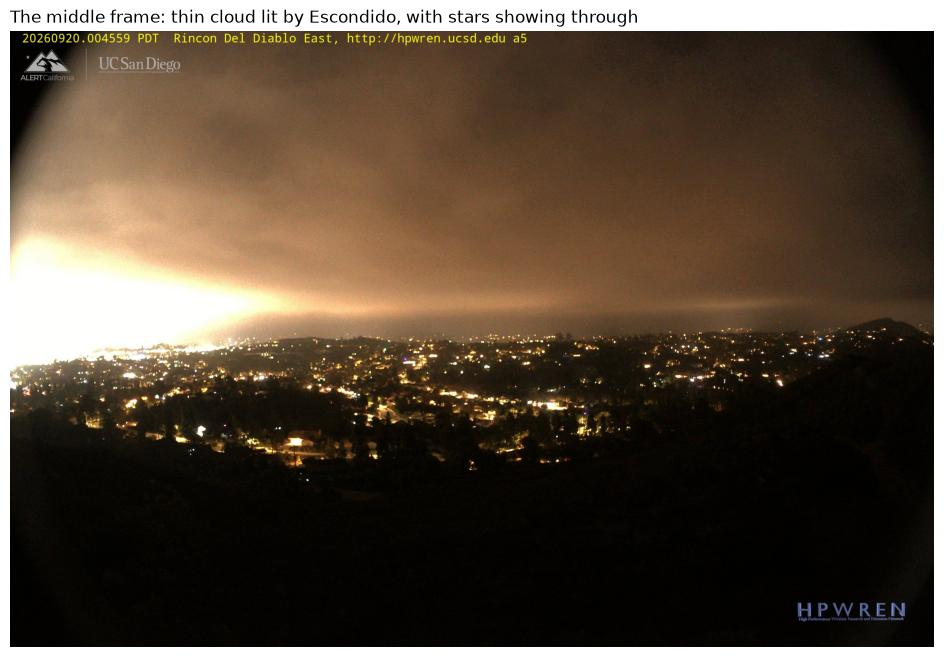

In [3]:
linked, decoded = collect(frames, lat=cam["lat"], lon=cam["lon"], max_gap_s=300)
H, W = next(iter(decoded.values()))[1].shape[:2]
mid = sorted(decoded)[len(decoded) // 2]
frame = decoded[mid][1]
show(frame, "The middle frame: thin cloud lit by Escondido, with stars showing through")

## 2. What linking finds

`collect` finds point sources in every frame and links them by nearest neighbour. It keeps
what persists for at least 8 frames and moves at least 50 px. Stars pass that test, but so does
the bright, mottled cloud near the glow: its texture shifts from frame to frame, and the linker
chains it into tracks.

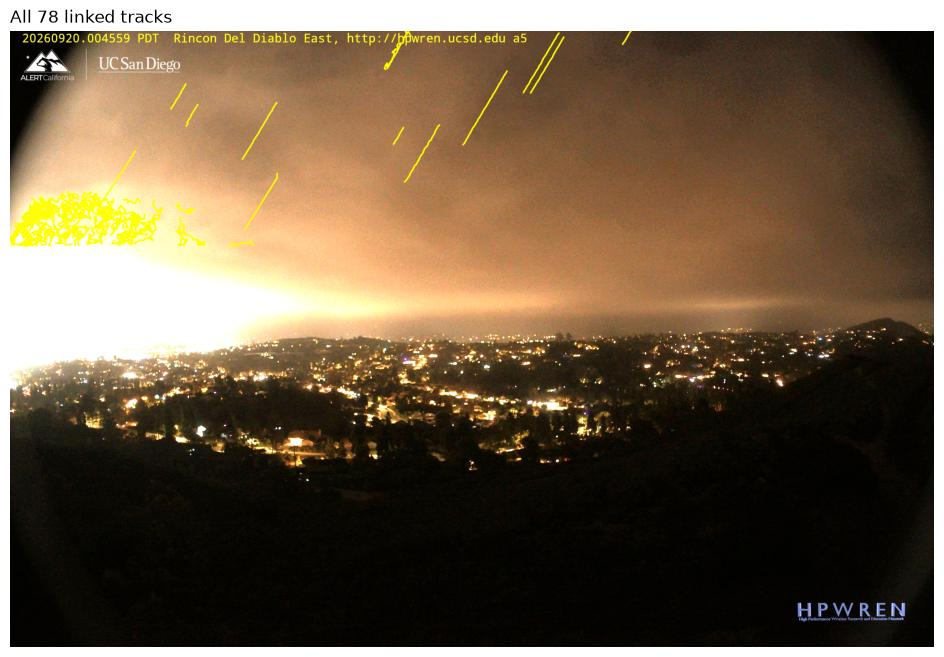

In [4]:
canvas = cv2.convertScaleAbs(frame, alpha=1.5, beta=0)
draw_tracks(canvas, linked, (0, 255, 255), 3)
show(canvas, f"All {len(linked)} linked tracks")

## 3. Telling a star from cloud texture

A star drifts. Between points at least 10 px apart, its direction of travel turns by a few
degrees at most. Cloud texture wanders: it turns sharply and often reverses. `tracks.shape`
measures both, and `tracks.wandering` flags a track whose median turn is over 40° or whose
reversals (turns over 90°) are more than 30% of its steps. Over the solved CDN blocks this
test flags 1.3% of the tracks that matched a star and 29% of the rest.

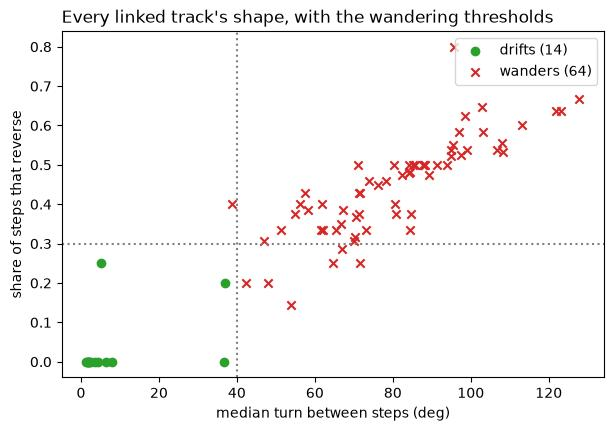

In [5]:
shapes = [shape(t) for t in linked]
flag = np.array([wandering(t) for t in linked])
turn = np.array([s["turn_deg"] for s in shapes])
rev = np.array([s["reversals"] for s in shapes])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(turn[~flag], rev[~flag], color="tab:green", label=f"drifts ({(~flag).sum()})")
ax.scatter(turn[flag], rev[flag], color="tab:red", marker="x", label=f"wanders ({flag.sum()})")
ax.axvline(40, color="grey", ls=":")
ax.axhline(0.3, color="grey", ls=":")
ax.set_xlabel("median turn between steps (deg)")
ax.set_ylabel("share of steps that reverse")
ax.set_title("Every linked track's shape, with the wandering thresholds", loc="left")
ax.legend()
plt.show()

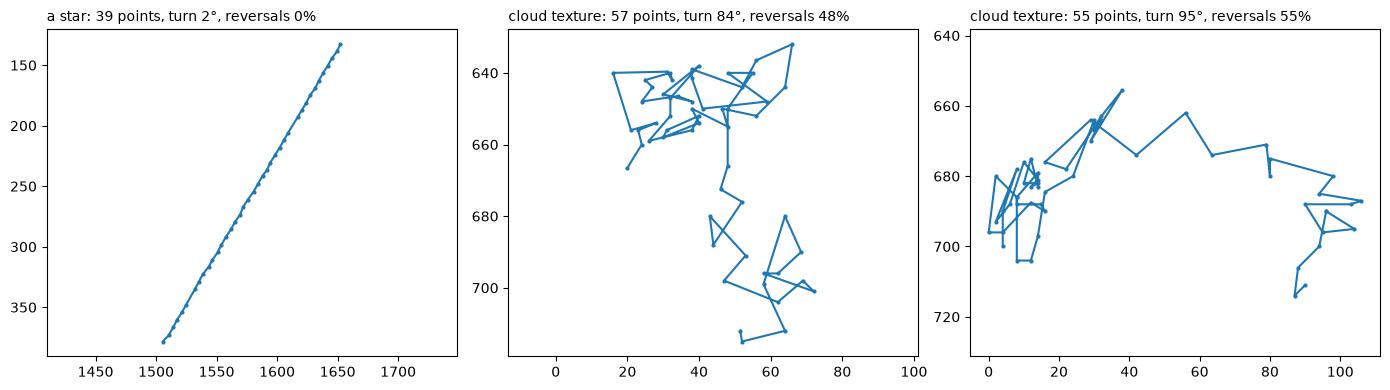

In [6]:
star = max((t for t, f in zip(linked, flag) if not f), key=len)
worst = sorted((i for i in range(len(linked)) if flag[i]), key=lambda i: -len(linked[i]))[:2]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (t, label) in zip(axes, [(star, "a star")] + [(linked[i], "cloud texture") for i in worst]):
    xy = np.array([t[o][:2] for o in sorted(t)])
    s = shape(t)
    ax.plot(xy[:, 0], xy[:, 1], "-o", ms=2)
    ax.invert_yaxis()
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(f"{label}: {len(t)} points, turn {s['turn_deg']:.0f}°, reversals {s['reversals']:.0%}",
                 loc="left", fontsize=10)
plt.tight_layout()
plt.show()

`clean` does more than drop wandering tracks. It splits a track the linker handed from one star
to another into its stars. It keeps the largest smooth part of a wandering track when that part
holds at least half its points, since that's usually a star with junk attached. It also removes
HPWREN's burned-in clock from the top 60 rows, and parts that repeat a longer track.

{'linked': 78, 'wandering': 64, 'split': 5, 'banner': 0, 'duplicate': 0, 'kept': 14}


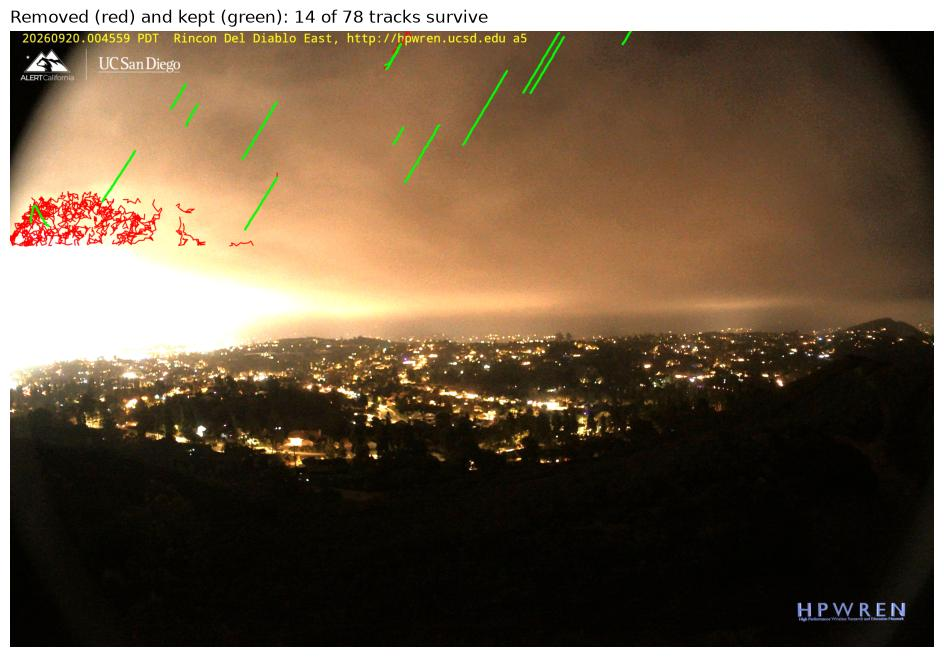

In [7]:
tracks, counts = clean(linked, banner_px=60)
print(counts)

canvas = cv2.convertScaleAbs(frame, alpha=1.5, beta=0)
draw_tracks(canvas, linked, (0, 0, 255), 2)
draw_tracks(canvas, tracks, (0, 255, 0), 5)
show(canvas, f"Removed (red) and kept (green): {len(tracks)} of {len(linked)} tracks survive")

## 4. The pole sees the difference before any star is named

The pole fit (see the first example) is told the sidereal rate, so a real star field returns
a pole of length |p| close to 1 under the right lens. Cloud texture doesn't rotate about the
pole at the sidereal rate, and it pulls the fit away.

In [8]:
k = fisheye.K_RATIO * fisheye.initial_k(cam, W)
for label, tr in (("all linked tracks", linked), ("cleaned tracks", tracks)):
    f = POLE.estimate(tr, W, H, k, fisheye.K1)
    print(f"{label:18s} |p| = {f['norm']:.3f}   inliers {f['inlier_frac']:.0%}   quality {f['quality']:.2f}")

all linked tracks  |p| = 0.863   inliers 95%   quality 0.48
cleaned tracks     |p| = 1.004   inliers 89%   quality 0.83


With every linked track, |p| comes out 14% short. With the cleaned tracks it's within half a
percent of 1.

## 5. Solving with and without cleaning

In [9]:
cx, cy = lookup(json.loads(intrinsics_path().read_text()), CAM, W, H, t0)
cam_c = {**cam, "cx": cx, "cy": cy}
results = {}
for label, tr in (("linked", linked), ("cleaned", tracks)):
    n = Night(camera=CAM, cam=cam_c, t0=t0, tracks=tr, W=W, H=H, label=f"{CAM} {DAY} Q1, {label}")
    results[label] = (n, solve_wide(n))
    r = results[label][1]
    print(f"{label:8s} {len(tr):3d} tracks -> {r['status']}: "
          + (f"{r['n_stars']} stars, median {r['median_px']:.2f} px" if r["status"] == "solved" else r["reason"]))
print(f"optical centre ({cx}, {cy}): this camera has too few solved nights for a fitted one")

linked    78 tracks -> failed: no start converged to >= 4 stars


cleaned   14 tracks -> solved: 13 stars, median 0.76 px
optical centre (0.0, 0.0): this camera has too few solved nights for a fitted one


The overlays show both. Without cleaning, the failure picture: every track the solver used
in cyan, and the bright stars in orange where the published pose and shared lens put them.
With cleaning, the solve: matched tracks in green with each star's fitted arc in magenta
inside it, the published pose's stars in orange, and yellow arrows from where the
published pose puts each star to where the fit has it.

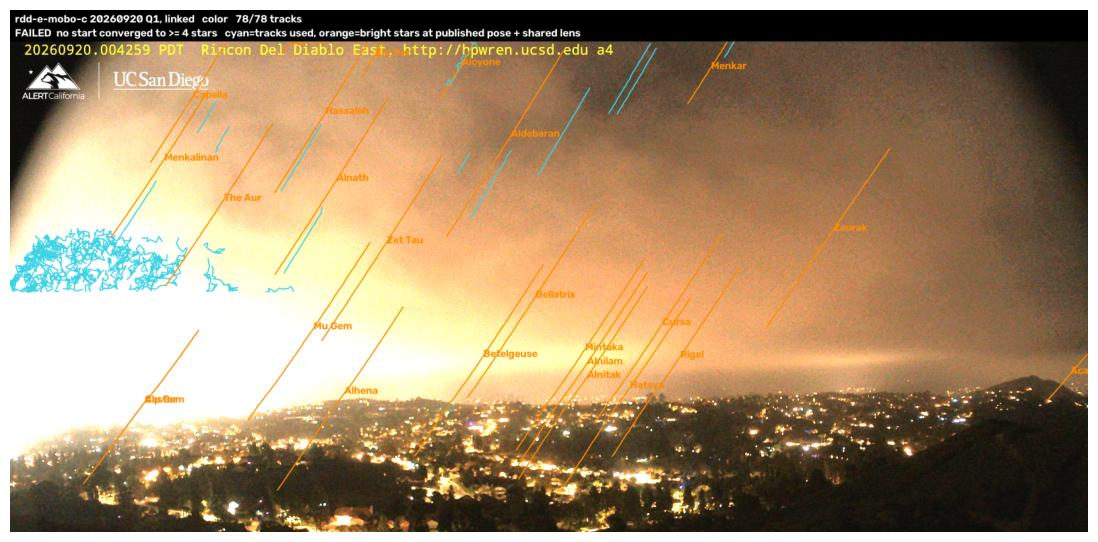

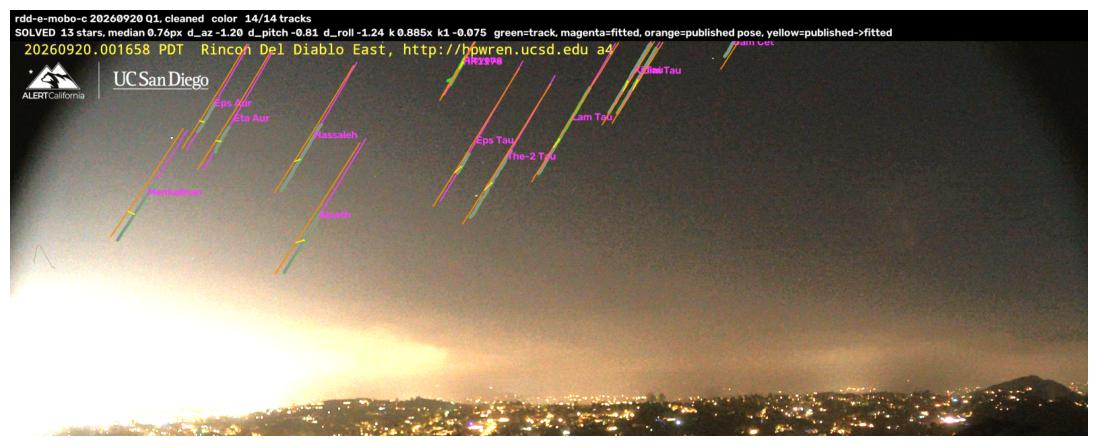

In [10]:
for label in ("linked", "cleaned"):
    n, r = results[label]
    ref = overlay.reference_offset(r, n)
    nearest = min(decoded, key=lambda o: abs(o - ref))
    show(overlay.draw(r, n, decoded[nearest][1]), width=14)

In [11]:
r = results["cleaned"][1]
p = r["pose"]
print(f"d_az {p['d_az']:+.3f}   d_pitch {p['d_pitch']:+.3f}   d_roll {p['d_roll']:+.3f} deg   "
      f"lens {p['k_ratio']:.3f}x, k1 {p['k1']:+.3f}")
for name in sorted(r["per_star_px"], key=lambda n: r["mags"][n]):
    print(f"  {name:14s} mag {r['mags'][name]:4.2f}   {r['per_star_px'][name]:.2f} px")

d_az -1.201   d_pitch -0.811   d_roll -1.237 deg   lens 0.885x, k1 -0.075
  Alnath         mag 1.65   0.87 px
  Menkalinan     mag 1.90   0.87 px
  Hassaleh       mag 2.69   0.47 px
  Alcyone        mag 2.85   0.54 px
  Eps Aur        mag 3.03   0.78 px
  Eta Aur        mag 3.18   0.99 px
  The-2 Tau      mag 3.40   1.27 px
  Lam Tau        mag 3.41   0.74 px
  Gam Cet        mag 3.47   1.14 px
  Eps Tau        mag 3.53   1.33 px
  Omi Tau        mag 3.61   0.57 px
  HR1178         mag 3.62   0.60 px
  Xi Tau         mag 3.73   0.55 px


## 6. A check that doesn't use the stars

Thirteen stars on a single night is enough to pass the acceptance test, but not by much, and
this camera has no second solved night to compare against: the night before had no coherent
sky rotation to fit.
So check the pose against terrain instead. On 26 September the morning was clear and the
mountains east of Escondido stood out against the sky.

`terrain.crests` marches rays across the camera's view through the Copernicus 30 m surface
model and returns every crest: the last point before the terrain behind it drops out of
sight. The skyline is yellow, inner crests magenta. They are projected through the published
pose with the shared lens, then through the solved pose.

The pose was measured on 20 September and the frame is from 26 September. That's only a fair
test if the camera didn't move in between. If it had, the solved pose wouldn't fit either.

('rdd-e-mobo-c', '20260926', 1, 1)


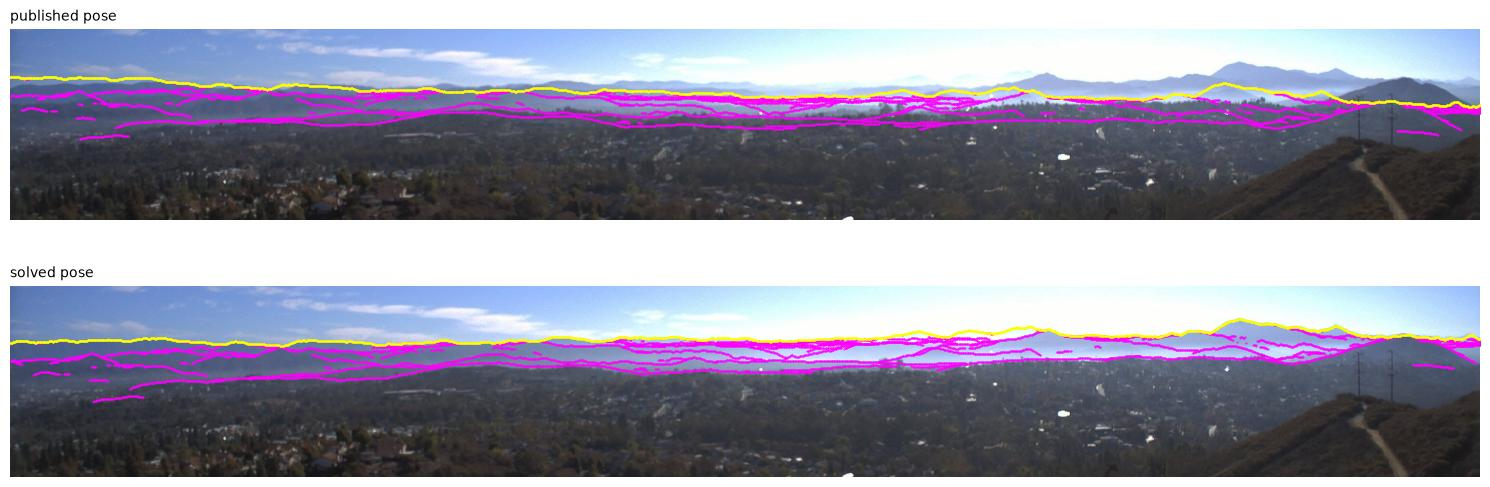

In [12]:
print(nights.fetch(CAM, DAY_TIME, q=4, n_frames=1))
day = cv2.imread(str(sorted((cache_dir() / "nights" / CAM / f"{DAY_TIME}_Q4").glob("*.jpg"))[0]))
c_az, c_el, c_km, c_sky = terrain.crests(cam)
views = {"published pose": terrain.project(cam, c_az, c_el, W, H),
         "solved pose": terrain.project(cam_c, c_az, c_el, W, H, pose=r["pose"])}

fig, axes = plt.subplots(2, 1, figsize=(15, 5.5))
for ax, (label, (x, y)) in zip(axes, views.items()):
    ax.imshow(cv2.cvtColor(day, cv2.COLOR_BGR2RGB))
    ax.plot(x[~c_sky], y[~c_sky], ".", ms=0.8, color="magenta")
    ax.plot(x[c_sky], y[c_sky], ".", ms=1.2, color="yellow")
    ax.set_xlim(0, W)
    ax.set_ylim(1250, 850)
    ax.set_axis_off()
    ax.set_title(label, loc="left", fontsize=10)
plt.tight_layout()
plt.show()

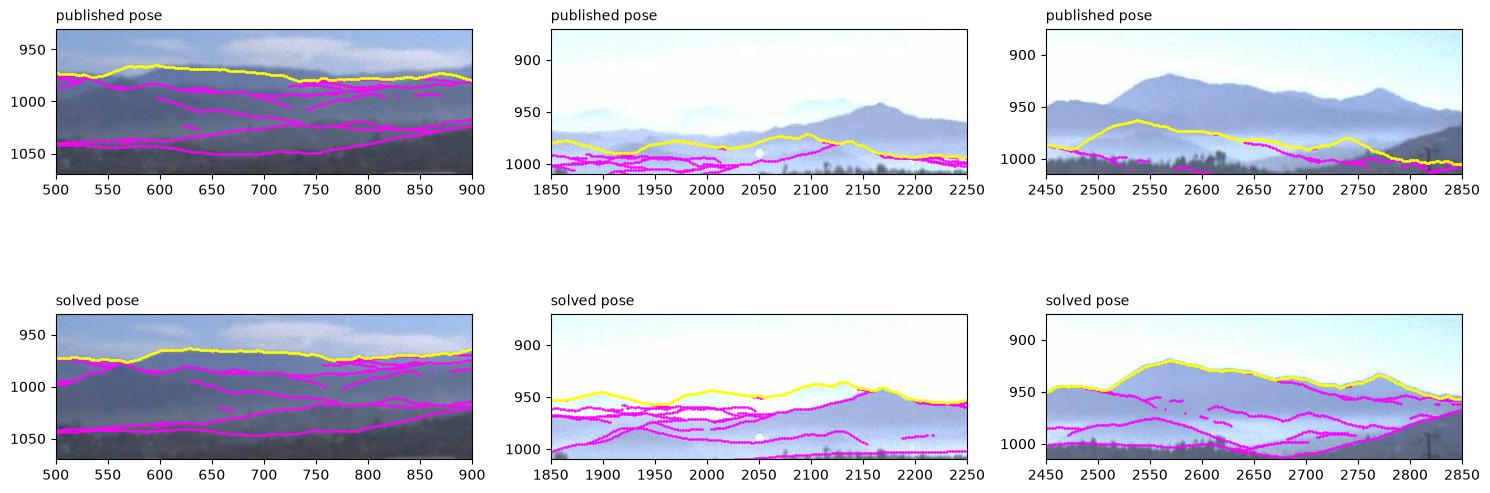

In [13]:
windows = [(700, 1000), (2050, 940), (2650, 945)]      # (x, y) centres
fig, axes = plt.subplots(2, len(windows), figsize=(15, 6.5))
for row, (label, (x, y)) in enumerate(views.items()):
    for col, (x0, y0) in enumerate(windows):
        ax = axes[row, col]
        ax.imshow(cv2.cvtColor(day, cv2.COLOR_BGR2RGB))
        m = (x > x0 - 200) & (x < x0 + 200)
        ax.plot(x[m & ~c_sky], y[m & ~c_sky], ".", ms=1.5, color="magenta")
        ax.plot(x[m & c_sky], y[m & c_sky], ".", ms=2, color="yellow")
        ax.set_xlim(x0 - 200, x0 + 200)
        ax.set_ylim(y0 + 70, y0 - 70)
        ax.set_title(label, loc="left", fontsize=10)
plt.tight_layout()
plt.show()

As in the first example, score each pose by how strongly its crests sit on edges that are
bright above and dark below, with every crest shifted up or down together. A right pose peaks
near zero shift.

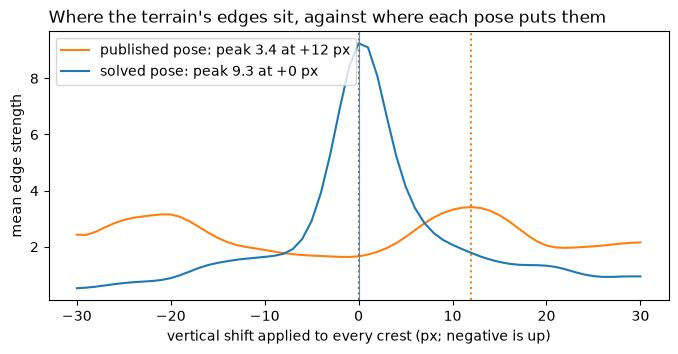

In [14]:
edge = terrain.edge_map(day)
shifts = np.arange(-30, 31)
fig, ax = plt.subplots(figsize=(8, 3.5))
for (label, (x, y)), colour in zip(views.items(), ("tab:orange", "tab:blue")):
    s = terrain.edge_score(edge, x, y, shifts)
    best = shifts[s.argmax()]
    ax.plot(shifts, s, color=colour, label=f"{label}: peak {s.max():.1f} at {best:+d} px")
    ax.axvline(best, color=colour, ls=":")
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("vertical shift applied to every crest (px; negative is up)")
ax.set_ylabel("mean edge strength")
ax.set_title("Where the terrain's edges sit, against where each pose puts them", loc="left")
ax.legend()
plt.show()

The solved crests trace the mountains across the frame, and the score peaks at zero shift. The
published pose has no such peak, because no vertical shift fixes it: its crests are tilted
against the real skyline by the 1.2° of roll the stars measured. A pose fitted from 13 stars
on one cloudy night predicts the terrain on a clear morning six days later.

## What to take from this

- On a night like this, most of what moves in the frame isn't a star. Without cleaning, the
  junk pulls the pole fit 14% short, and no start of the search converges.
- The wandering test needs nothing but each track's own shape: no catalog and no pose.
- A solve near the acceptance floor deserves an independent check. Here terrain supplies
  one. A second solved night would supply another.

Camera frames: HPWREN, <https://www.hpwren.ucsd.edu/>. Terrain: Copernicus DEM GLO-30.